# EWS-Credit UMOA — Analyse exploratoire et resultats du modele

Notebook autonome : il ne lit que les fichiers deja generes dans `data/synthetic/`
(CSV et Parquet), sans dependre d'un cluster Spark, d'une API ou de Docker actifs.

Si `data/synthetic/` est vide ou incomplet, regenerer via :
```
ews-credit portfolio
ews-credit events
docker compose up -d && docker/ingest_to_hdfs.sh && docker/run_spark_job.sh
```
(voir le README pour la chaine complete). Ce notebook lit le resultat final de
cette chaine, pas les donnees brutes.


In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, auc

DONNEES = Path("../data/synthetic")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11


## 1. Chargement des donnees

In [2]:
clients = pd.read_csv(DONNEES / "clients.csv", encoding="utf-8")
credits = pd.read_csv(DONNEES / "credits.csv", encoding="utf-8")
panel = pd.read_csv(DONNEES / "panel_mensuel.csv", encoding="utf-8", parse_dates=["date_releve"])
labels = pd.read_csv(DONNEES / "labels.csv", encoding="utf-8", parse_dates=["date_releve"])
features = pd.read_parquet(DONNEES / "features")
predictions = pd.read_parquet(DONNEES / "predictions_test")
analyse_pays = pd.read_parquet(DONNEES / "analyse_risque_pays")

fichiers_metriques = sorted((DONNEES / "metriques_modele").glob("part-*.json"))
fichier_metriques = next(f for f in fichiers_metriques if f.stat().st_size > 0)
metriques = json.loads(fichier_metriques.read_text().splitlines()[0])

print(f"{len(clients):,} clients | {len(credits):,} credits | {len(panel):,} lignes de panel mensuel")
print(f"{len(features):,} lignes de features (Spark) | {len(predictions):,} predictions de test")


15,000 clients | 18,391 credits | 259,270 lignes de panel mensuel
255,051 lignes de features (Spark) | 62,662 predictions de test


## 2. Vue d'ensemble du portefeuille

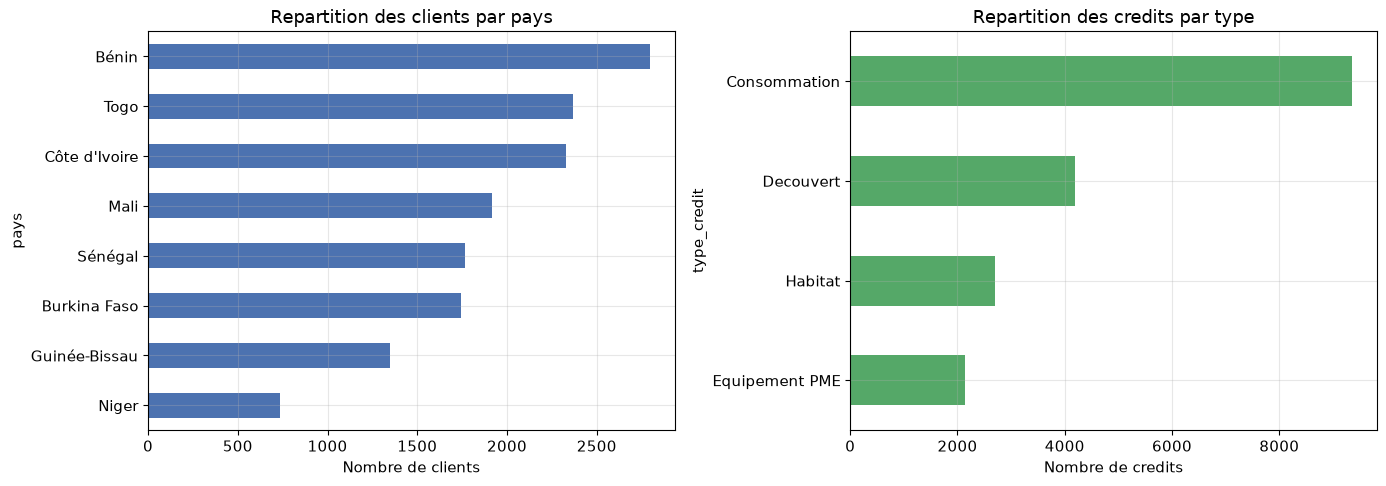

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clients["pays"].value_counts().sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Repartition des clients par pays")
axes[0].set_xlabel("Nombre de clients")

credits["type_credit"].value_counts().sort_values().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Repartition des credits par type")
axes[1].set_xlabel("Nombre de credits")

plt.tight_layout()
plt.show()


## 3. Evolution temporelle du risque

Le generateur simule un choc macro (avril-septembre de la premiere annee), calibre
sur le vrai bond de provisionnement observe par la BCEAO entre 2019 et 2020 (x7).
On doit le retrouver ici comme une hausse visible de la part de credits degrades.

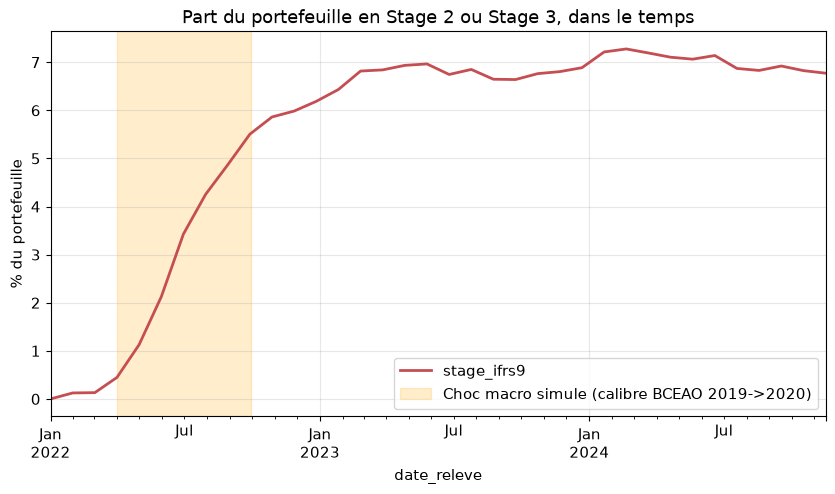

In [4]:
evolution = panel.groupby("date_releve")["stage_ifrs9"].apply(lambda s: (s >= 2).mean() * 100)

fig, ax = plt.subplots()
evolution.plot(ax=ax, color="#C44E52", linewidth=2)
ax.axvspan(pd.Timestamp("2022-04-01"), pd.Timestamp("2022-09-30"), color="orange", alpha=0.2,
           label="Choc macro simule (calibre BCEAO 2019->2020)")
ax.set_title("Part du portefeuille en Stage 2 ou Stage 3, dans le temps")
ax.set_ylabel("% du portefeuille")
ax.legend()
plt.show()


## 4. Features comportementales (Spark) : lien avec le risque de defaut

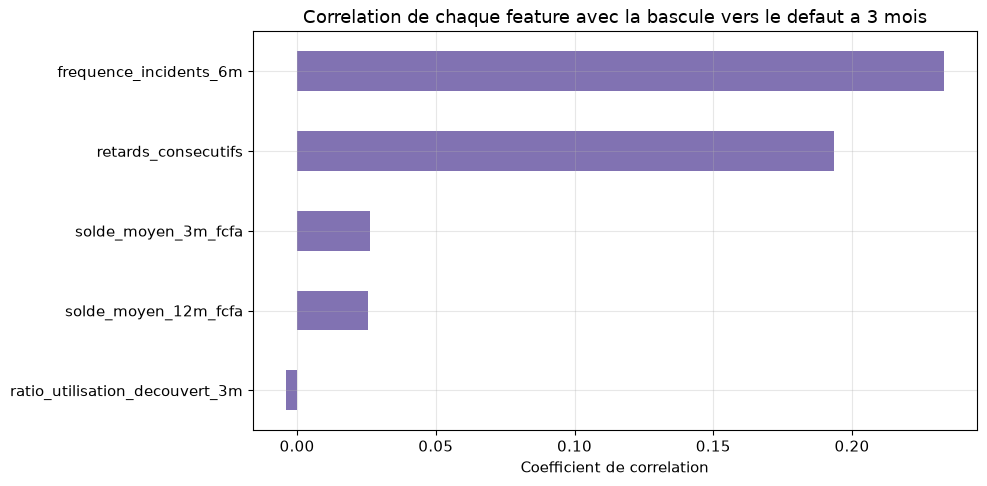

In [5]:
labels_avec_mois = labels.copy()
labels_avec_mois["annee_mois"] = labels_avec_mois["date_releve"].dt.strftime("%Y-%m")

dataset = features.merge(
    labels_avec_mois[["credit_id", "annee_mois", "bascule_defaut_3m"]],
    on=["credit_id", "annee_mois"],
)

colonnes_features = [
    "retards_consecutifs", "solde_moyen_3m_fcfa", "solde_moyen_12m_fcfa",
    "ratio_utilisation_decouvert_3m", "frequence_incidents_6m",
]
correlations = dataset[colonnes_features + ["bascule_defaut_3m"]].corr()["bascule_defaut_3m"]
correlations = correlations.drop("bascule_defaut_3m").sort_values()

fig, ax = plt.subplots()
correlations.plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Correlation de chaque feature avec la bascule vers le defaut a 3 mois")
ax.set_xlabel("Coefficient de correlation")
plt.tight_layout()
plt.show()


## 5. Analyse Spark SQL : risque par pays et par mois

Résultat déjà agrégé par le job `spark_jobs/sql_analysis.py` (requête SQL déclarative, pas recalculé ici).

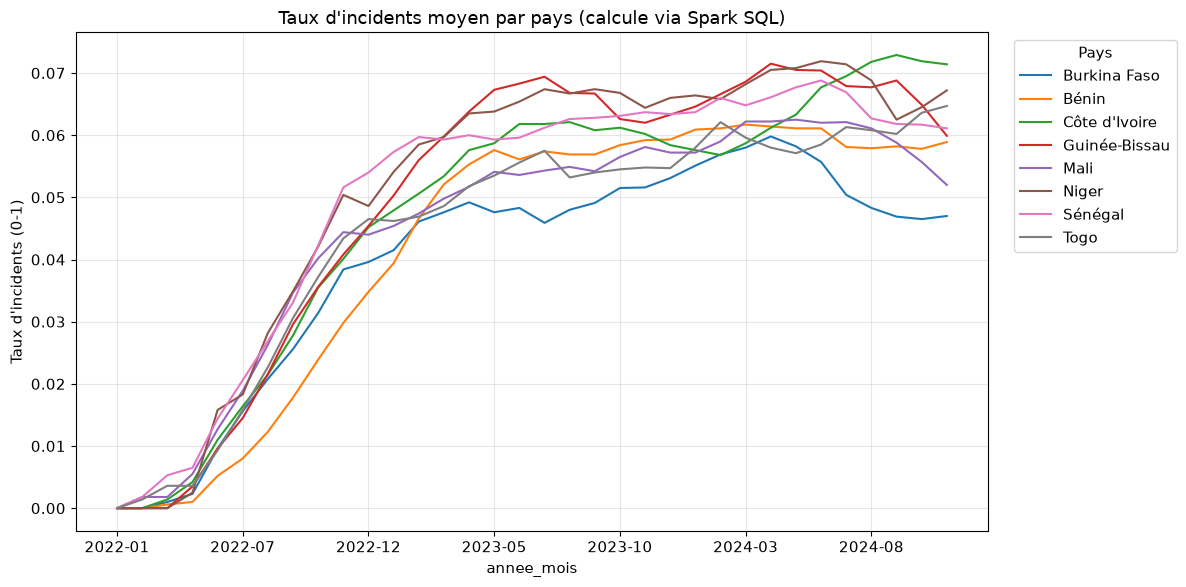

In [6]:
pivot = analyse_pays.pivot(index="annee_mois", columns="pays", values="taux_incidents_moyen")

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(ax=ax)
ax.set_title("Taux d'incidents moyen par pays (calcule via Spark SQL)")
ax.set_ylabel("Taux d'incidents (0-1)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Pays")
plt.tight_layout()
plt.show()


## 6. Resultats du modele de Machine Learning

Regression logistique (Spark MLlib), poids de classe equilibres pour compenser le
fort desequilibre (~0.9% de bascules vers le defaut). Evaluee sur un jeu de test
independant (25% des donnees, jamais vu a l'entrainement).

In [7]:
print("Metriques (jeu de test) :")
for cle, valeur in metriques.items():
    print(f"  {cle:28s} {valeur}")


Metriques (jeu de test) :
  auc_pr                       0.0965
  auc_roc                      0.9218
  f1_classe_positive           0.1379
  precision_classe_positive    0.0756
  rappel_classe_positive       0.7857


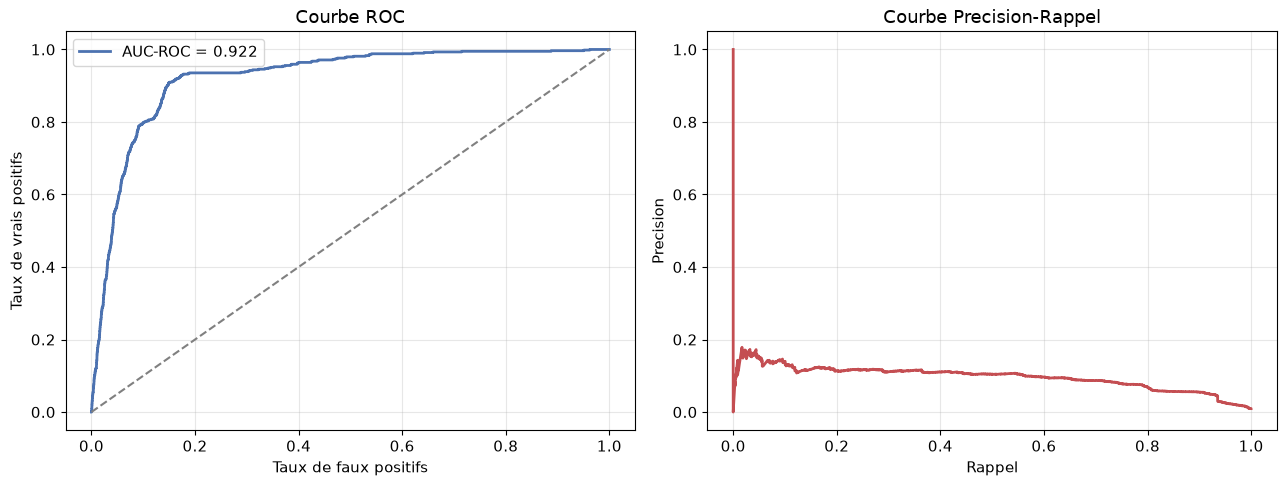

In [8]:
fpr, tpr, _ = roc_curve(predictions["bascule_defaut_3m"], predictions["proba_positif"])
precision, recall, _ = precision_recall_curve(predictions["bascule_defaut_3m"], predictions["proba_positif"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color="#4C72B0", linewidth=2, label=f"AUC-ROC = {auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("Courbe ROC")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].legend()

axes[1].plot(recall, precision, color="#C44E52", linewidth=2)
axes[1].set_title("Courbe Precision-Rappel")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.show()


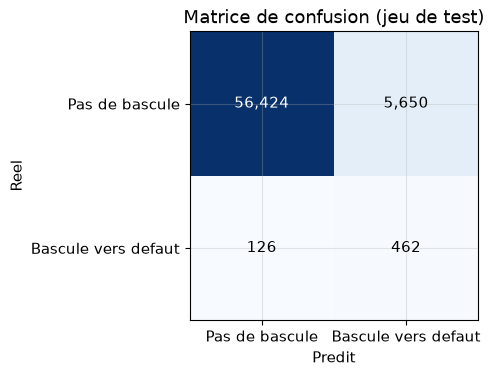

In [9]:
matrice = confusion_matrix(predictions["bascule_defaut_3m"], predictions["prediction"])

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(matrice, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matrice[i, j]:,}", ha="center", va="center",
                color="white" if matrice[i, j] > matrice.max() / 2 else "black")
ax.set_xticks([0, 1], labels=["Pas de bascule", "Bascule vers defaut"])
ax.set_yticks([0, 1], labels=["Pas de bascule", "Bascule vers defaut"])
ax.set_xlabel("Predit")
ax.set_ylabel("Reel")
ax.set_title("Matrice de confusion (jeu de test)")
plt.tight_layout()
plt.show()


## 7. Synthese

- Le choc macro simule (calibre sur le vrai bond de provisionnement BCEAO 2019->2020)
  se retrouve clairement dans l'evolution temporelle du portefeuille (section 3).
- Les features comportementales issues du pipeline Spark (retards consecutifs,
  frequence d'incidents) sont correlees positivement avec le risque de defaut, ce
  qui valide la pertinence du feature engineering distribue (section 4).
- Le modele entraine (regression logistique poids-equilibree) detecte environ
  **79% des vraies bascules vers le defaut** (rappel) avec un AUC-ROC de **0.92** —
  un signal statistique solide pour un premier modele, complementaire au score par
  regles explicites (`domain/scoring.py`) deja utilise par l'API et le dashboard.
- Piste d'amelioration : un modele non lineaire (GBTClassifier) ou un rappel de
  variables supplementaires (donnees macro BCEAO en serie temporelle) pourrait
  ameliorer la precision sans sacrifier le rappel.
